In [46]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as smp
from sympy.polys.polyfuncs import interpolate
from matplotlib.pyplot import figure
from scipy.interpolate import CubicSpline
from scipy.interpolate import PchipInterpolator
import ipywidgets as widgets
from ipywidgets import interact
from scipy.interpolate import UnivariateSpline
import scipy.stats as stats

## Задание 1. Закон всемирного тяготения

Используем метод для вычисления силы взаимного притяжения Луны и Земли. Для простоты предположим, что плотности Земли и Луны не зависят от координат и возьмем их средние значения. Для проведения численного эксперимента нам понадобятся следующие физические величины:

\begin{aligned}
&G = 6.67 \cdot 10^{-11} \frac{\text{Н} \cdot \text{м}^2}{\text{кг}^2} \text{ — гравитационная постоянная;} \\
&m_1 = 6 \cdot 10^{24} \text{ кг} \text{ — масса Земли;} \\
&m_2 = 7.35 \cdot 10^{22} \text{ кг} \text{ — масса Луны;} \\
&r = 384467000 \text{ м} \text{ — расстояние между Луной и Землей;} \\
&\rho_1 = 5520 \frac{\text{кг}}{\text{м}^3} \text{ — средняя плотность Земли;} \\
&\rho_2 = 3346 \frac{\text{кг}}{\text{м}^3} \text{ — средняя плотность Луны;} \\
&R_1 = 6367000 \text{ м} \text{ — радиус Земли;} \\
&R_2 = 1737000 \text{ м} \text{ — радиус Луны.}
\end{aligned}

Поскольку тела сферические со сферически симметричной функцией плотности (константой), то объекты можно рассматривать как точечные и вычислить их силу притяжения по формуле:

$$ F = G \frac{m_1 \cdot m_2}{r^2}, $$

где $m_1$ и $m,_2$ массы точечных объектов. Это значение будем использовать для сравнения с результатами вычислений с помощью метода Монте-Карло. По формуле находим значение силы

$$ F = 1.98997 \cdot 10^{20} \text{H}. $$

Результаты вычислений этой силы с помощью метода Монте-Карло и аналитически сравнить между собой. Построить график зависимости ошибки от числа итераций в логарифмическом масштабе , сделать вывод об асимптотике ошибки.

In [2]:
def sphere_uniform(radius):
    r = radius * np.random.rand()
    phi = 2*np.pi*np.random.rand()
    theta = np.pi*np.random.rand()
    
    out = np.empty(3)
    
    out[0] = r*np.cos(phi)*np.sin(theta)
    out[1] = r*np.sin(phi)*np.sin(theta)
    out[2] = r*np.cos(theta)
    
    return out

In [3]:
center_distance = 384467000
r_earth = 6367000
r_moon = 1737000
rho_earth = 5520
rho_moon = 3346
m_earth = 6*10**24
m_moon = 7.35*10**22
G = 6.67 * 10**(-11)
V_earth = (4/3) * np.pi * r_earth**3
V_moon = (4/3) * np.pi * r_moon**3

r0 = [center_distance+0.5*(r_earth+r_moon), 0, 0]

In [4]:
N = np.logspace(1, 7, 20).astype(int)

r = np.empty((N[-1]+1, 3))
for j in range(len(r)):
    r[j] = r0 + sphere_uniform(r_earth) - sphere_uniform(r_moon)

f = np.empty((N[-1]+1, 3))
f[0] = r[0]/np.linalg.norm(r[0])**3
for i in range(len(f)):
    f[i] = f[i-1]+r[i]/np.linalg.norm(r[i])**3

In [5]:
F = np.empty(len(N))
for i in range(len(F)):
    # F[i] = np.linalg.norm(f[N[i]])*G*rho_earth*rho_moon*V_earth*V_moon/N[i]
    F[i] = np.linalg.norm(f[N[i]])*G*m_earth*m_moon/N[i]

true_F = G * m_earth * m_moon / np.linalg.norm(r0)**2
error = np.abs(F - true_F)/true_F

Ожидаем $ ln \epsilon \sim -0.5 ln N $

In [6]:
def line(t, a, b):
    return np.e**b*t**a

In [7]:
def on_change(a, b):
    plt.loglog(N, error, 'o', N, line(N, a, b))
    plt.show()

    -0.5
interact(on_change, a=widgets.FloatSlider(value=-0.5, min=-1, max=0, step=0.01), 
         b=widgets.FloatSlider(value=np.log(error[0]*N[0]**0.5), min=-5, max=5, step=0.01))

interactive(children=(FloatSlider(value=-0.5, description='a', max=0.0, min=-1.0, step=0.01), FloatSlider(valu…

<function __main__.on_change(a, b)>

## Задание 2. Закон всемирного тяготения

Пусть на однородную пластинку бесконечной площади толщиной $h$ нормально падает поток нейтронов с энергией $E_0$. При столкновении с атомами вещества, из которого состоит пластинка, нейтроны могут: а) упруго рассеиваться; б) поглощаться. Пусть при упругом рассеянии: энергия не меняется; равновероятно любое направление рассеяния. Сечения поглощения и сечения рассеяния нейтронов считать известными. Требуется вычислить:

* вероятность прохождения нейтрона сквозь пластинку $P_+$,
* вероятность отражения нейтронов от пластинки $P_-$,
* вероятность поглощения нейтрона в пластинке $P_0$.

In [8]:
absorb = 0.2 
scat = 0.7
total_sigma = absorb + scat

h = 1
n = 1
l = 1/(n*total_sigma)

N_neut = 1000000

In [9]:
pass_count = 0
reflect_count = 0
absorb_count = 0

for i in range(N_neut):
    x = 0
    v_x = 1
    
    while True:
        x += v_x*np.random.exponential(l)
        
        if x > h:
            pass_count += 1
            break
        if x < 0:
            reflect_count += 1
            break
        
        collision = total_sigma*np.random.rand()
        if (collision < absorb):
            absorb_count += 1
            break
        
        v_x = sphere_uniform(1)[0]
        
total_count = pass_count + reflect_count + absorb_count

print('P+ =', pass_count/total_count)
print('P- =', reflect_count/total_count)
print('P0 =', absorb_count/total_count)

P+ = 0.509787
P- = 0.134667
P0 = 0.355546


## Задание 3. Случайное блуждание

Рассмотрим одномерное случайное блуждание, где на каждом шаге с вероятностью $1/2$ точка движется влево или вправо на единицу длины. Чему равно математическое ожидание расстояния точки от нуля после $T$ шагов?

Вычислите аналитически, затем промоделируйте численно.
Проанализируйте погрешность (нарисовать график и гистограмму).

In [17]:
def random_walk(T, iterations):
    x = np.full(iterations, 0)

    for i in range(iterations):
        for j in range(T):
            if np.random.rand() < 0.5:
                x[i] += 1
            else:
                x[i] -= 1

    return x

In [22]:
destinations = random_walk(100, 1000000)

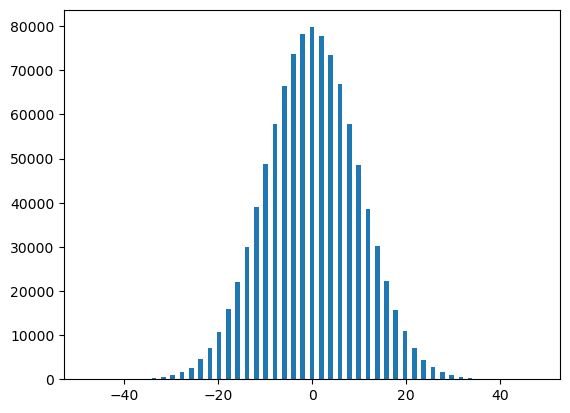

In [26]:
plt.hist(destinations, bins=destinations.max()-destinations.min()+1)
plt.show()

In [37]:
T = np.linspace(1, 1000, 100).astype(int)
E = np.empty(len(T))

for i in range(len(T)):
    result = random_walk(T[i], 1000)
    E[i] = np.mean(np.abs(result))

In [41]:
def E_theory(T):
    return np.sqrt(2 * T / np.pi)

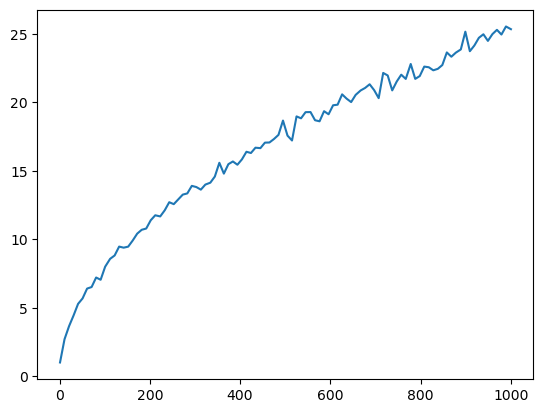

In [42]:
plt.plot(T, E)
plt.show()

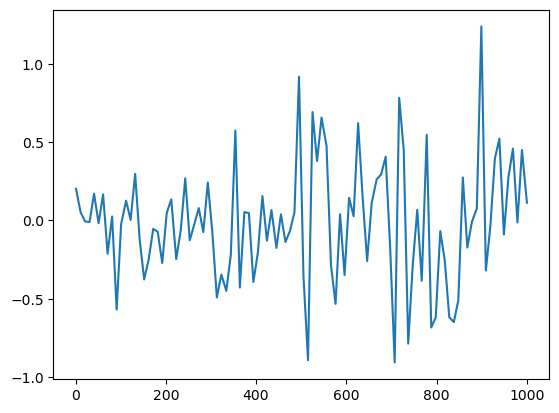

In [43]:
plt.plot(T, E-E_theory(T))
plt.show()

## Задание 4. Семплирование по Гиббсу

Семплируйте по Гиббсу сумму двух гауссианов из разобранного примера на алгоритм Метрополиса-Хастингса.

In [77]:
def Hibbs(x=0, B=0.1, D=1000000):
    xs = np.zeros(D+1)
    xs[0] = x

    for i in range(1, D+1):
        xs[i] = xs[i-1] + np.random.uniform(-B, B)
    
    return xs[1:]

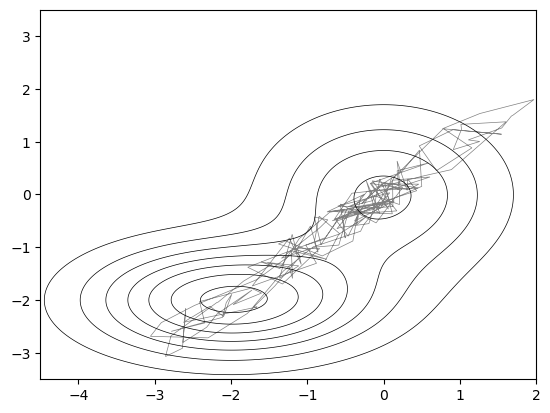

In [122]:
delta = 0.025
X, Y = np.meshgrid(np.arange(-4.5, 2.0, delta), np.arange(-3.5, 3.5, delta))

z1 = stats.multivariate_normal([0, 0], [[1.0, 0], [0, 1.0]])
z2 = stats.multivariate_normal([-2, -2], [[1.5, 0], [0, 0.5]])

def z(x):
    return 0.4 * z1.pdf(x) + 0.6 * z2.pdf(x)

samples = np.empty((0, 2))
r = np.zeros(2)

last = 0
for i in range(200):
    rq = Hibbs(x=last, D=2, B=0.5)
    a = z(rq) / z(r)
    
    if np.random.rand() < min(a, 1):
        r = rq
        last = rq[-1]
        samples = np.append(samples, [r], axis=0)
        
codes = np.ones(len(samples), int) * path.Path.LINETO
codes[0] = path.Path.MOVETO

p = path.Path(samples, codes)

fig, ax = plt.subplots()

# Add contour lines
Z1 = 0.4 * z1.pdf(np.dstack((X, Y)))
Z2 = 0.6 * z2.pdf(np.dstack((X, Y)))
Z = Z1 + Z2
contour = ax.contour(X, Y, Z, colors='black', linewidths=0.5)

# Add the path
patch = patches.PathPatch(p, facecolor='none', lw=0.5, edgecolor='gray')
ax.add_patch(patch)

ax.set_xlim(-4.5, 2.0)
ax.set_ylim(-3.5, 3.5)
plt.show()

## Задание 5. Алгоритм Метрополиса-Хастингса - генерация выборок

Сгенерируйте выборку из функции плотности $\pi(x) \sim \exp(-x^2) (3 + \cos(x) + 2\sin(x) + x^2)$, применив алгоритм Метрополиса-Хастингса к случайному блужданию $x_{t+1} = x_t + \varepsilon_t$, где $\varepsilon_t \sim N(0, 1)$.

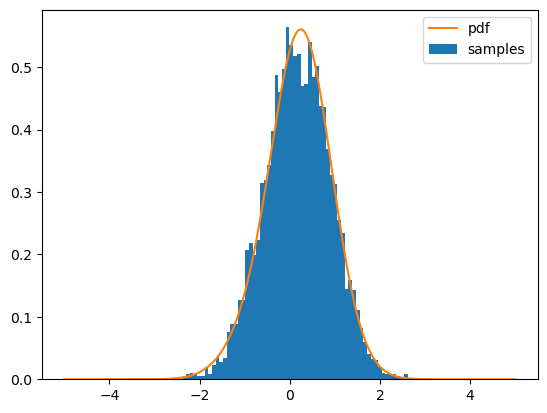

In [74]:
def z(x):
    return np.exp(-x**2) * (3 + np.cos(x) + 2*np.sin(x) + x**2)

samples = np.empty(0)
r = 0

for i in range(10000):
    rq = np.random.normal(0, 1) + r
    a = z(rq) / z(r)
    
    if np.random.rand() < min(a, 1):
        r = rq
        samples = np.append(samples, r)
        
grid = np.linspace(-5, 5, 10000)
pdf = z(grid)
pdf /= 0.001*np.sum(pdf)

plt.hist(samples, bins=61, density=True)
plt.plot(grid, pdf)
plt.legend(['pdf', 'samples'])
plt.show()